In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
train_data = pd.read_csv("train_KNN.csv")
test_data = pd.read_csv("test_KNN.csv")

print("Training Data:")
print(train_data.head())

print("\nTesting Data:")
print(test_data.head())

Training Data:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   Na

In [5]:
print(train_data.info())
print(train_data.describe())

# Check missing values
print(train_data.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None
       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.48659

In [6]:
X_train = train_data.iloc[:, :-1]
y_train = train_data.iloc[:, -1]

X_test = test_data.iloc[:, :-1]
y_test = test_data.iloc[:, -1]

In [9]:
print(train_data.columns)

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')


In [10]:
train_data = train_data.drop(['Name', 'Ticket', 'Cabin'], axis=1, errors='ignore')
test_data = test_data.drop(['Name', 'Ticket', 'Cabin'], axis=1, errors='ignore')

In [11]:
train_data = pd.get_dummies(train_data)
test_data = pd.get_dummies(test_data)

In [12]:
train_data, test_data = train_data.align(test_data, join='left', axis=1, fill_value=0)

In [13]:
X_train = train_data.iloc[:, :-1]
y_train = train_data.iloc[:, -1]

X_test = test_data.iloc[:, :-1]
y_test = test_data.iloc[:, -1]

In [15]:
# Fill numeric columns with mean
train_data = train_data.fillna(train_data.mean(numeric_only=True))
test_data = test_data.fillna(test_data.mean(numeric_only=True))

In [16]:
# Handle missing values
train_data = train_data.fillna(train_data.mean(numeric_only=True))
test_data = test_data.fillna(test_data.mean(numeric_only=True))

In [18]:
print(X_train.isnull().sum().sum())

177


In [20]:
import pandas as pd
from sklearn.linear_model import LinearRegression

# Load data
train_data = pd.read_csv("train_KNN.csv")
test_data = pd.read_csv("test_KNN.csv")

# Drop unwanted text columns
train_data = train_data.drop(['Name', 'Ticket', 'Cabin'], axis=1, errors='ignore')
test_data = test_data.drop(['Name', 'Ticket', 'Cabin'], axis=1, errors='ignore')

# Convert categorical to numeric
train_data = pd.get_dummies(train_data)
test_data = pd.get_dummies(test_data)

# Align columns
train_data, test_data = train_data.align(test_data, join='left', axis=1, fill_value=0)

# 🔥 Handle ALL missing values (important)
train_data = train_data.fillna(0)
test_data = test_data.fillna(0)

# Split features & target
X_train = train_data.iloc[:, :-1]
y_train = train_data.iloc[:, -1]

X_test = test_data.iloc[:, :-1]
y_test = test_data.iloc[:, -1]

# 🔍 Double check (VERY IMPORTANT)
print("NaN in X_train:", X_train.isnull().sum().sum())
print("NaN in X_test:", X_test.isnull().sum().sum())

# Train model
model = LinearRegression()
model.fit(X_train, y_train)

print("Model trained successfully ✅")

NaN in X_train: 0
NaN in X_test: 0
Model trained successfully ✅


In [21]:
y_pred = model.predict(X_test)

print("Predictions:")
print(y_pred[:5])

Predictions:
[ 1.69822334e-04  9.89819561e-01 -5.72763054e-03  1.00004230e+00
  9.95392497e-01]


In [22]:
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R2 Score:", r2)

Mean Squared Error: 4.2956075239675635e-05
R2 Score: 0.999812175743489


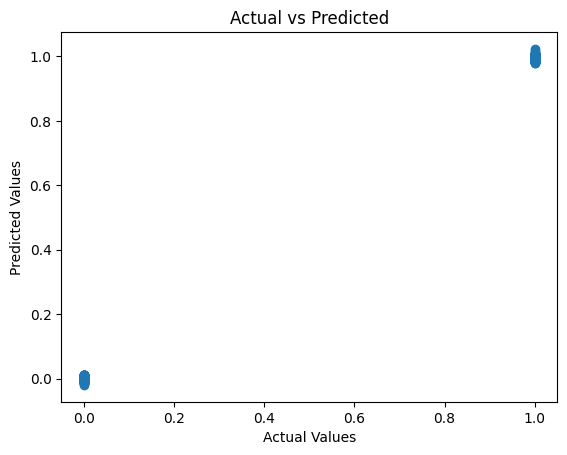

In [23]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted")
plt.show()

Conclusion.
Regression analysis helps in predicting continuous values based on input data. In this lab, we built a linear regression model, trained it using data, and evaluated its performance using metrics like MSE and R² score. This shows how machine learning can be used for real-world predictions.